# Dependencies

In [43]:
import numpy as np
import pandas as pd
import pickle
from scipy.stats import mode

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import hdbscan

from scipy.spatial import procrustes
from sklearn.preprocessing import MinMaxScaler
import umap

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.cm import get_cmap
import matplotlib.gridspec as gridspec

In [2]:
L = 4500 # original length
tp = 1
l = int(L/tp) # after patch
N = 20
D = 192
sample_frequency = 9

fmr1_fold_1 = {"train":[402, 404, 405, 406, 407, 408], "valid": [401, 403]}
fmr1_fold_2 = {"train":[401, 403, 405, 406, 407, 408], "valid": [402, 404]}
fmr1_fold_3 = {"train":[401, 402, 403, 404, 407, 408], "valid": [405, 406]}
fmr1_fold_4 = {"train":[401, 402, 404, 405, 406, 407], "valid": [403, 408]}

# Load Representations

In [4]:
# Representations learned from the pre-trained skeletonMAE
#tr_feats = np.load('./t3/representations/mae_sdannce_tr.npy')[:, 40:1540]
#val_feats = np.load('./t3/representations/mae_sdannce_val.npy')[:, 40:1540]
tr_feats = np.load('/home/rguo_hpc/myfolder/mocap/outputs/representations/fmr1/t1/representations/mae_sdannce_tr.npy')[:, 120:4620][:,::sample_frequency]
val_feats = np.load('/home/rguo_hpc/myfolder/mocap/outputs/representations/fmr1/t1/representations/mae_sdannce_val.npy')[:, 120:4620][:,::sample_frequency]
feats = np.concatenate([tr_feats, val_feats])
print(tr_feats.shape, val_feats.shape)

# Representations learned after mil
#mil_feats = np.load('/home/rguo_hpc/myfolder/mocap/mil/savemodel/InceptBackbone/sdannce/exp_72/representations.npy')[:, 41:1541]
#mil_feats = np.load('./18_71/mil/representations.npy')[:, 40:1540]

mil_feats = np.load('/home/rguo_hpc/myfolder/mocap/mil/savemodel/InceptBackbone/sdannce/tpatch_1/representations.npy')[:, 1:][:,::sample_frequency]
print(mil_feats.shape)
mil_tr_feats = mil_feats[:tr_feats.shape[0]]
mil_val_feats = mil_feats[tr_feats.shape[0]:]

(360, 500, 192) (120, 500, 192)
(480, 500, 192)


## Load Labels

In [7]:
# load original data 
with open("/home/rguo_hpc/myfolder/data/sdannce/data_fmr1.pkl", 'rb') as file:
    result = pickle.load(file)


for mouse in result.keys():     # result.keys(): [408, 407, 404, 403, 402, 406, 405, 401]
    num_seq = len(result[mouse]["ratgen"])
    ratgen  = int(result[mouse]["ratgen"][0])
    result[mouse]["ratgen"] = [ratgen for i in range(num_seq * N,)]
    ratid = result[mouse]["ratid"][0]
    result[mouse]["ratid"] = [ratid for i in range(num_seq * N,)]
    
    # llac    
    llac = np.array(result[mouse]["llac"])
    llac = np.squeeze(llac, axis=2)
    llac = llac.reshape(-1, L,)
    if tp > 1:
        grouped_llac = llac.reshape(-1, l, tp) # choose the mode label of each patch 
        result[mouse]["llac"] = mode(grouped_llac, axis=2, keepdims=False).mode.astype(np.uint8)
    else:
        result[mouse]["llac"] = llac
    
    # hlac
    hlac = np.array(result[mouse]["hlac"]) # (3, 90000, 1)
    hlac = np.squeeze(hlac, axis=2)
    hlac = hlac.reshape(-1, L,)
    if tp > 1:
        grouped_hlac = hlac.reshape(-1, l, 3)
        result[mouse]["hlac"] = mode(grouped_hlac, axis=2, keepdims=False).mode.astype(np.uint8)
    else:
        result[mouse]["hlac"] = hlac
    
    del result[mouse]["m1"]

## Process 

In [8]:
# Train: mouse, genotype, hlac, llac
mouse_tr, gen_tr, hlac_tr, llac_tr = [], [], [], []
for mouse_id in fmr1_fold_1["train"]:
    mouse_tr.append(result[mouse_id]["ratid"])
    gen_tr.append(result[mouse_id]["ratgen"])
    hlac_tr.append(result[mouse_id]["hlac"])
    llac_tr.append(result[mouse_id]["llac"])
    
mouse_tr = np.repeat(np.concatenate(mouse_tr), l)[::sample_frequency]
gen_tr =  np.repeat(np.concatenate(gen_tr), l)[::sample_frequency]
hlac_tr = np.concatenate(hlac_tr)[:,::sample_frequency]
llac_tr = np.concatenate(llac_tr)[:,::sample_frequency]

# Val:  mouse, genotype, hlac, llac
mouse_val, gen_val, hlac_val, llac_val = [], [], [], []
for mouse_id in fmr1_fold_1["valid"]:
    mouse_val.append(result[mouse_id]["ratid"])
    gen_val.append(result[mouse_id]["ratgen"])
    hlac_val.append(result[mouse_id]["hlac"])
    llac_val.append(result[mouse_id]["llac"]) 
    
mouse_val = np.repeat(np.concatenate(mouse_val), l)[::sample_frequency]
gen_val = np.repeat(np.concatenate(gen_val), l)[::sample_frequency]
hlac_val = np.concatenate(hlac_val)[:,::sample_frequency]
llac_val = np.concatenate(llac_val)[:,::sample_frequency]

In [9]:
# Merge + sample
mouse_labels = np.concatenate([mouse_tr, mouse_val])
gen_labels = np.concatenate([gen_tr, gen_val])
hlac_labels = np.concatenate([hlac_tr, hlac_val])
llac_labels = np.concatenate([llac_tr, llac_val])
num_seq = hlac_labels.shape[0]
seq_ids = np.repeat(np.arange(480), int(l/sample_frequency)) # repeat each element l times
frame_ids = np.tile(np.arange(int(l/sample_frequency)), 480)

### pretrained feats

In [33]:
# PCA
feats_norm = normalize(feats.reshape(-1, D), norm='l2')
feats_pca = PCA(n_components=96, random_state=42)
feats_pca.fit(feats_norm)
feats_pca_embeddings = feats_pca.transform(feats_norm)
print(feats_pca_embeddings.shape)

feats_cumvar = np.cumsum(feats_pca.explained_variance_ratio_)
print(f"Variance explained by 50 PCs: {feats_cumvar[-1]:.1%}")

(240000, 96)
Variance explained by 50 PCs: 99.6%


In [34]:
# Cluster 
kmeans = KMeans(n_clusters=9, random_state=0, n_init=10, max_iter=200)
labels = kmeans.fit_predict(feats_pca_embeddings)

In [39]:
ari = adjusted_rand_score(labels, hlac_labels.reshape(hlac_labels.size, ))
nmi = normalized_mutual_info_score(labels, mil_labels)
print(f"ARI = {ari:.4f} | NMI = {nmi:.4f}  (near 1 = clusters preserved, near 0 = reorganized)")

ARI = 0.0158 | NMI = 0.0462  (near 1 = clusters preserved, near 0 = reorganized)


In [ ]:
score = silhouette_score(feats_pca_embeddings, labels)
print(score)
# 0.16,,

### mil feats

In [28]:
# Mil
mil_feats_norm = normalize(mil_feats.reshape(-1, D), norm='l2')
mil_feats_pca = PCA(n_components=96, random_state=42)
mil_feats_pca.fit(mil_feats_norm)
mil_feats_pca_embeddings = mil_feats_pca.transform(mil_feats_norm)
print(mil_feats_pca_embeddings.shape)

mil_feats_cumvar = np.cumsum(mil_feats_pca.explained_variance_ratio_)
print(f"Variance explained by 96 PCs: {mil_feats_cumvar[-1]:.1%}")

(240000, 64)
Variance explained by 96 PCs: 95.0%


In [19]:
# Mil Cluster
mil_kmeans = KMeans(n_clusters=9, random_state=0, n_init=10, max_iter=200)
mil_labels = mil_kmeans.fit_predict(mil_feats_pca_embeddings)

In [ ]:
mil_score = silhouette_score(mil_feats_pca_embeddings, mil_labels)
print(mil_score)
# 0.10196316987276077

### UMAP

In [22]:
## UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42, low_memory=True,)
feats_pca_2d = reducer.fit_transform(feats_pca_embeddings)
np.save("feats_pca_2d.npy", feats_pca_2d)

/home/rguo_hpc/.conda/envs/moseq/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [23]:
mil_reducer = umap.UMAP(n_components=2, n_neighbors=30,      # larger = more global structure
                        min_dist=0.1, metric='euclidean', random_state=42, low_memory=True,)
mil_feats_pca_2d = mil_reducer.fit_transform(mil_feats_pca_embeddings)
np.save("mil_feats_pca_2d.npy", mil_feats_pca_2d)

/home/rguo_hpc/.conda/envs/moseq/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [20]:
feats_pca_2d = np.load("t1/feats_pca_2d.npy")
mil_feats_pca_2d = np.load("t1/mil_feats_pca_2d.npy")

# Align two space

### 0. Transform

In [26]:
mtx1, mtx2, disparity = procrustes(feats_pca_embeddings, mil_feats_pca_embeddings)
print(disparity)
# Rescale both together or independently
#scaler = MinMaxScaler(feature_range=(0, 1))
#mtx1 = scaler.fit_transform(mtx1)
#mtx2 = scaler.transform(mtx2)

0.9433566744840917


### Sol1. Fit UMAP on mtx1, mtx2 respectively

In [ ]:
mtx1_reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42, low_memory=True,)
mtx1_2d = mtx1_reducer.fit_transform(mtx1)
np.save("mtx1_2d.npy", mtx1_2d)

In [ ]:
mtx2_reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42, low_memory=True,)
mtx2_2d = mtx2_reducer.fit_transform(mtx2)
np.save("mtx2_2d.npy", mtx2_2d)

In [30]:
mtx1_2d = np.load("mtx1_2d.npy")
mtx2_2d = np.load("mtx2_2d.npy")

### Sol2. Combine + umap (not good)

In [ ]:
# cluster
combined = np.vstack([mtx1, mtx2])
#combined = np.vstack([feats_pca_embeddings , mil_feats_pca_embeddings])
combined_kmeans = KMeans(n_clusters=9, random_state=42, n_init=10, max_iter=200)
combined_labels = combined_kmeans.fit_predict(combined)

#combined_reducer = umap.UMAP(n_components=2, n_neighbors=40, min_dist=0.1,random_state=42, low_memory=True,)
#proj = combined_reducer.fit_transform(combined)
#np.save("combined_pca_2d.npy", proj)

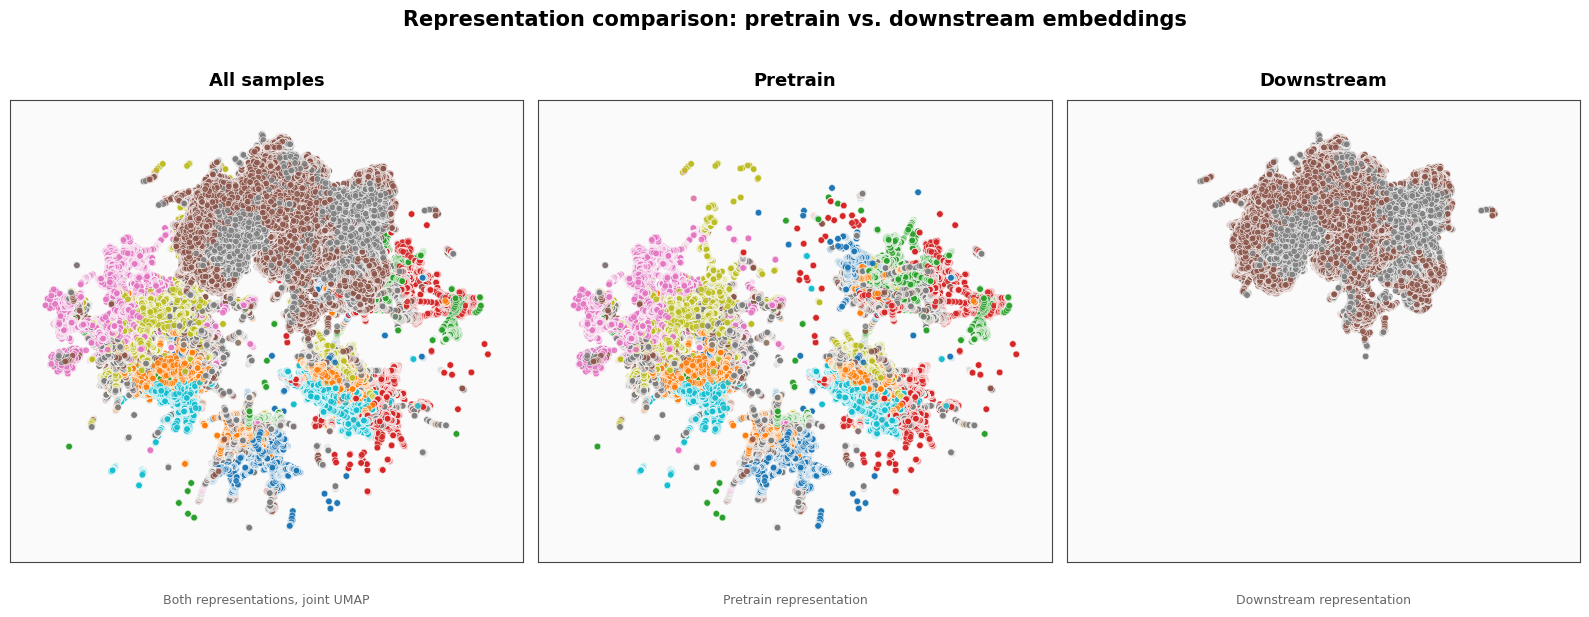

In [37]:
#proj = np.vstack([feats_pca_2d, mil_feats_pca_2d])
#proj_pre, labels_pre = feats_pca_2d, combined_labels[:half_n]
#proj_down, labels_down = mil_feats_pca_2d, combined_labels[half_n:]

proj = np.vstack([mtx1_2d, mtx2_2d])
half_n = len(proj) // 2    # Assuming 'proj' (n, 2) and 'labels' (n,) are already defined
proj_pre, labels_pre = mtx1_2d, combined_labels[:half_n]
proj_down, labels_down = mtx2_2d, combined_labels[half_n:]

# shared axis limits across all 3 panels so they're directly comparable
pad = 0.08 * (proj[:, 0].max() - proj[:, 0].min())
xlim = (proj[:, 0].min() - pad, proj[:, 0].max() + pad)
ylim = (proj[:, 1].min() - pad, proj[:, 1].max() + pad)
cmap = plt.get_cmap("tab10")
 
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.linewidth"] = 0.8
 
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True, sharey=True)
fig.patch.set_facecolor("white")
 
panel_data = [
    (proj[:, 0], proj[:, 1], combined_labels, "All samples", "Both representations, joint UMAP"),
    (proj_pre[:, 0], proj_pre[:, 1], labels_pre, "Pretrain", "Pretrain representation"),
    (proj_down[:, 0], proj_down[:, 1], labels_down, "Downstream", "Downstream representation"),
]
vmin, vmax = combined_labels.min(), combined_labels.max()

for ax, (x, y, labels, short_title, subtitle) in zip(axes, panel_data):
    ax.scatter(x, y, c=labels, cmap=cmap, s=22, alpha=0.85, linewidths=0.4, edgecolors="white", vmin=vmin, vmax=vmax,)
    ax.set_title(short_title, fontsize=13, fontweight="bold", pad=10)
    ax.text(0.5, -0.09, subtitle, transform=ax.transAxes, ha="center", fontsize=9, color="#666666")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#fafafa")
 
fig.suptitle("Representation comparison: pretrain vs. downstream embeddings",
             fontsize=15, fontweight="bold", y=1.02)
 
plt.tight_layout()
plt.show()

# Visualization

In [44]:
df = pd.DataFrame({
    'umap_x':       feats_pca_2d[:, 0],
    'umap_y':       feats_pca_2d[:, 1],
    'cluster':      labels,
    'mil_umap_x':   mil_feats_pca_2d[:, 0],
    'mil_umap_y':   mil_feats_pca_2d[:, 1],
    'mil_cluster':  mil_labels,
    'seq_id':       seq_ids,           # 0..num_sequences
    'frame_idx':    frame_ids,         # 0..1199
    'mouse_label':  mouse_labels,#[frame_ids + seq_ids*l][::sample_frequency],  # broadcast to frame level
    'gen_label':     gen_labels,
    'hlac_label':    hlac_labels.reshape(hlac_labels.size, ),
    'llac_label': llac_labels.reshape(llac_labels.size, )
})

In [45]:
def filter_dataframe_multiple(df, filters):
    """
    Example filter:{ "city": ["Berlin", "Paris"],"age": [25, 30]}
    """
    mask = pd.Series(True, index=df.index)
    for column, values in filters.items():
        mask &= df[column].isin(values)
    return df[mask].copy()

In [46]:
def plot_cluster_landscape(df, umap_x='umap_x', umap_y='umap_y', cluster_label = 'cluster', figsize=(14, 6)):
    """
    Left : UMAP colored by cluster
    Right: Bar chart of cluster sizes, sorted largest → smallest
    """
    n_clusters = df[cluster_label].nunique()
    cmap = get_cmap('tab20', n_clusters)
    colors = {c: cmap(i) for i, c in enumerate(sorted(df[cluster_label].unique()))}

    cluster_sizes = df[cluster_label].value_counts().sort_index()
    cluster_pcts  = cluster_sizes / len(df) * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [1.4, 1]})

    # --- Left: UMAP scatter ---
    for c, grp in df.groupby(cluster_label):
        ax1.scatter(grp[umap_x], grp[umap_y], color=colors[c], s=0.3, alpha=0.4, rasterized=True)

    # Annotate each cluster centroid with its ID
    for c, grp in df.groupby(cluster_label):
        cx, cy = grp[umap_x].mean(), grp[umap_y].mean()
        ax1.text(cx, cy, str(c), fontsize=7, fontweight='bold', ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, lw=0))

    ax1.set_title('UMAP — colored by cluster', fontsize=11)
    ax1.axis('off')

    # --- Right: bar chart sorted by size ---
    sorted_clusters = cluster_sizes.sort_values(ascending=False).index
    bar_colors = [colors[c] for c in sorted_clusters]
    sizes_sorted = cluster_sizes[sorted_clusters]
    pcts_sorted  = cluster_pcts[sorted_clusters]

    bars = ax2.barh(range(len(sorted_clusters)), sizes_sorted.values,
                    color=bar_colors, edgecolor='white', linewidth=0.5)

    # Annotate bars with percentage
    for i, (bar, pct) in enumerate(zip(bars, pcts_sorted)):
        ax2.text(bar.get_width() + sizes_sorted.max() * 0.01, i,
                 f'{pct:.1f}%', va='center', fontsize=8, color='#444')

    ax2.set_yticks(range(len(sorted_clusters)))
    ax2.set_yticklabels([f'C{c}' for c in sorted_clusters], fontsize=8)
    ax2.invert_yaxis()
    ax2.set_xlabel('Number of frames')
    ax2.set_title('Cluster sizes', fontsize=11)
    ax2.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    #plt.savefig('cluster_landscape.pdf', dpi=150, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_626228/3367255011.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', n_clusters)


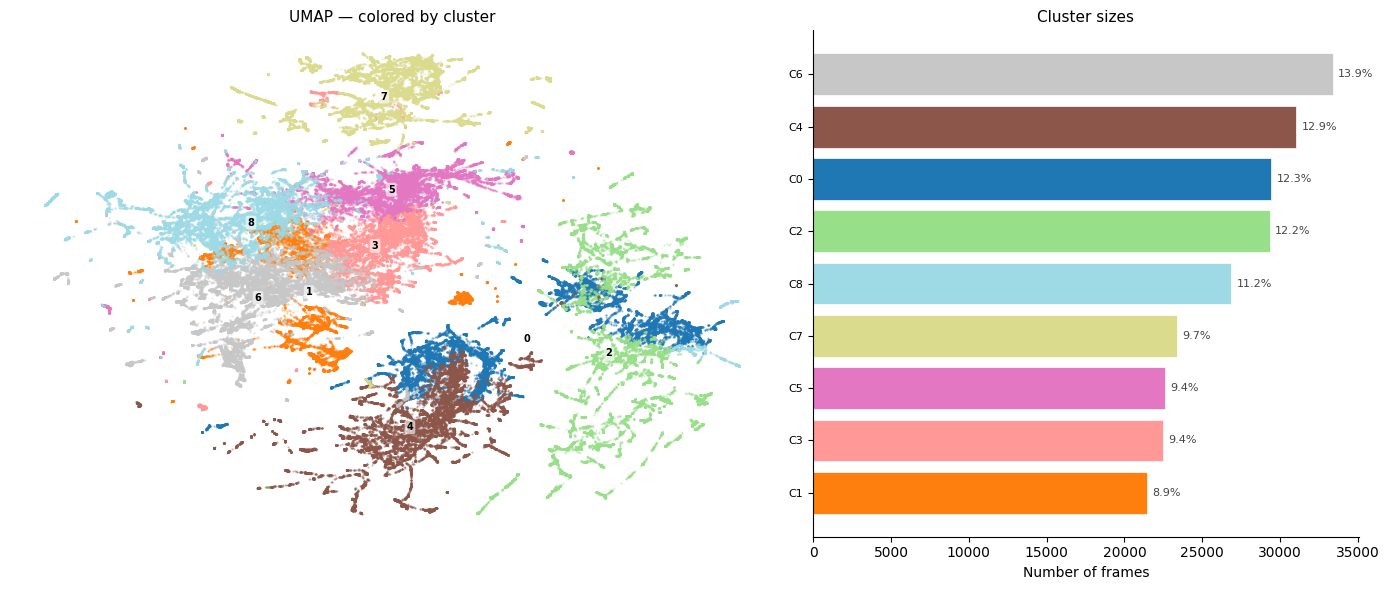

In [47]:
plot_cluster_landscape(df)

In [ ]:
plot_cluster_landscape(df, 'mil_umap_x',  'mil_umap_y', 'mil_cluster')

In [ ]:
## KDE plot

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def _subsample(data, max_points, random_state=0):
    if len(data) > max_points:
        return data.sample(max_points, random_state=random_state)
    return data


def plot_umap_kde(df,x_col="mil_umap_x", y_col="mil_umap_y", gen_col="gen_label", cluster_col="mil_cluster",
                 figsize=(19, 6), fill_levels=8, cmap="viridis", gridsize=80,       # seaborn default 200; lower = much faster, slightly coarser
                ):
    """
    3-panel KDE comparison of UMAP embedding: all frames / gen_label=0 / gen_label=1.
    All panels share the same x/y limits AND the same color scale, so densities
    are directly comparable. A single shared colorbar denotes probability density.
    """
    # guard against stray whitespace in column names (e.g. "gen_label ")
    df = df.rename(columns=lambda c: c.strip())
    x_col, y_col = x_col.strip(), y_col.strip()
    gen_col = gen_col.strip()

    # shared axis limits across all 3 panels
    x_min, x_max = df[x_col].min(), df[x_col].max()
    y_min, y_max = df[y_col].min(), df[y_col].max()
    pad_x = (x_max - x_min) * 0.05
    pad_y = (y_max - y_min) * 0.05
    xlim = (x_min - pad_x, x_max + pad_x)
    ylim = (y_min - pad_y, y_max + pad_y)

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharex=True, sharey=True)

    subsets = [("All frames", df), ("gen_label = 0", df[df[gen_col] == 0]),("gen_label = 1", df[df[gen_col] == 1]),]

    last_contour = None
    for ax, (title, sub) in zip(axes, subsets):
        kde = sns.kdeplot(data=sub, x=x_col, y=y_col, fill=True, cmap=cmap,
                          thresh=0.05, levels=fill_levels, ax=ax, gridsize=gridsize,)
        # grab the underlying contour set for the shared colorbar
        if kde.collections:
            last_contour = kde.collections[-1]

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(f"{title}  (n={len(sub)})")

    plt.tight_layout(rect=[0, 0, 0.93, 1])  # leave room on the right for colorbar

    # single shared colorbar (probability density, relative scale)
    if last_contour is not None:
        cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
        cbar = fig.colorbar(last_contour, cax=cbar_ax)
        cbar.set_label("Estimated probability density", rotation=270, labelpad=15)

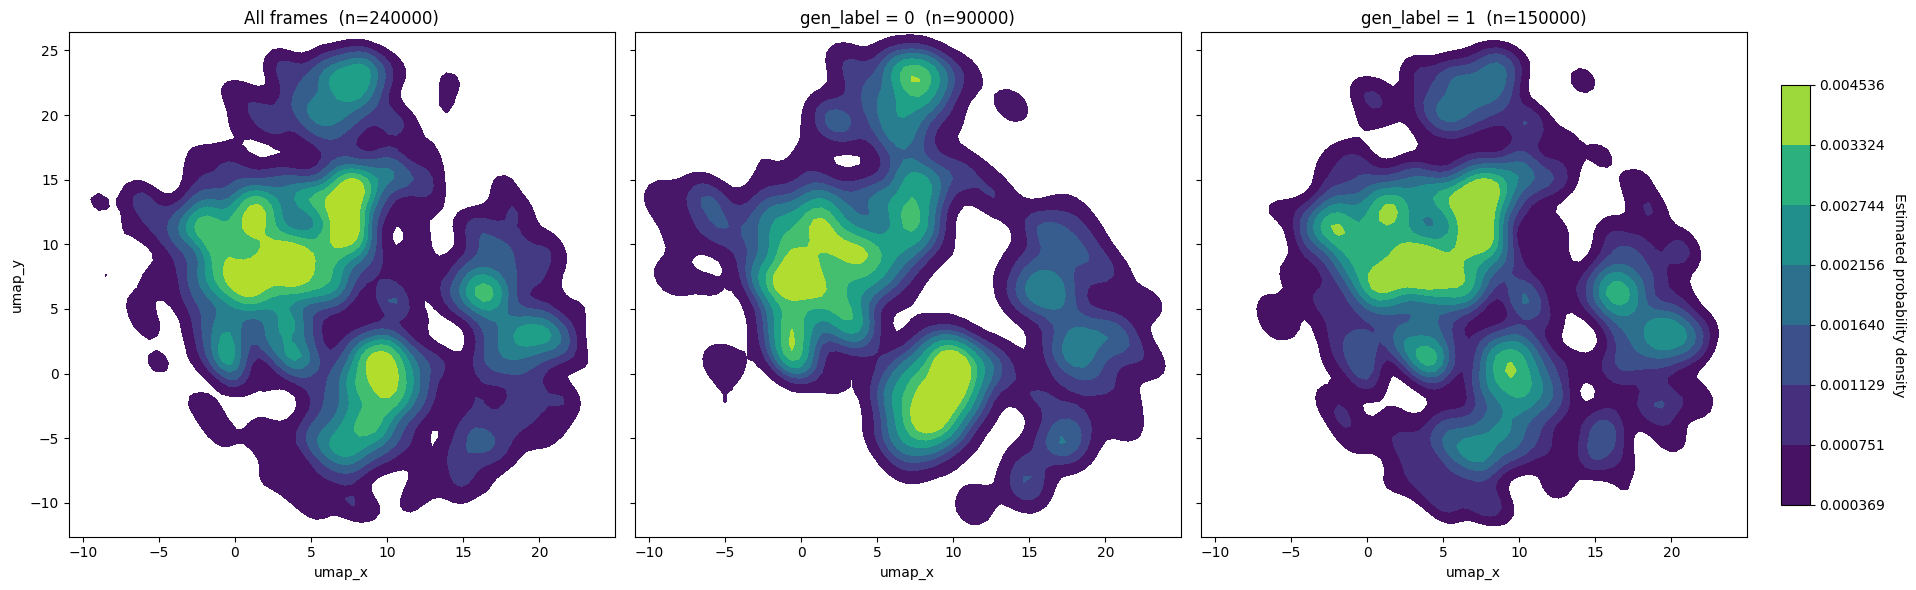

In [50]:
plot_umap_kde(df, x_col="umap_x", y_col="umap_y", gen_col="gen_label", cluster_col="cluster")

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


def plot_umap_kde(df, x_col="umap_x", y_col="umap_y", gen_col="gen_label", cluster_col="cluster",
    figsize=(19, 6), fill_levels=8, cmap="viridis", gridsize=80,                  # seaborn default is 200; lower = faster, slightly coarser
    ):
    """
    3-panel KDE comparison of UMAP embedding: all frames / gen_label=0 / gen_label=1.
    All panels share the same x/y limits AND the same color scale, so densities
    are directly comparable. A single shared colorbar denotes probability density.
    """
    # guard against stray whitespace in column names (e.g. "gen_label ")
    df = df.rename(columns=lambda c: c.strip())
    x_col, y_col = x_col.strip(), y_col.strip()
    gen_col = gen_col.strip()

    # shared axis limits across all 3 panels
    x_min, x_max = df[x_col].min(), df[x_col].max()
    y_min, y_max = df[y_col].min(), df[y_col].max()
    pad_x = (x_max - x_min) * 0.05
    pad_y = (y_max - y_min) * 0.05
    xlim = (x_min - pad_x, x_max + pad_x)
    ylim = (y_min - pad_y, y_max + pad_y)

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharex=True, sharey=True)

    subsets = [("All frames", df), ("gen_label = 0", df[df[gen_col] == 0]), ("gen_label = 1", df[df[gen_col] == 1]),]
    last_contour = None
    for ax, (title, sub) in zip(axes, subsets):
        kde = sns.kdeplot(data=sub, x=x_col, y=y_col, fill=True, cmap=cmap,
                          thresh=0.05, levels=fill_levels, ax=ax, gridsize=gridsize,)
        # grab the underlying contour set for the shared colorbar
        if kde.collections:
            last_contour = kde.collections[-1]

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(f"{title}  (n={len(sub)})")

    plt.tight_layout(rect=[0, 0, 0.93, 1])  # leave room on the right for colorbar

    # single shared colorbar (probability density, relative scale)
    if last_contour is not None:
        cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
        cbar = fig.colorbar(last_contour, cax=cbar_ax)
        cbar.set_label("Estimated probability density", rotation=270, labelpad=15)

    return fig


def score_discriminative_frames(df, x_col="umap_x", y_col="umap_y", gen_col="gen_label",
                                bw_method=None, eps=1e-12,):
    """
    Fit a separate 2D KDE for gen_label==0 and gen_label==1, then evaluate both
    at every frame's own (x, y) location. Adds columns:
      - density_0, density_1 : each class's density at that point
      - log_ratio            : log(density_1) - log(density_0)
                                 >> 0  -> point sits in a region dominated by class 1
                                 << 0  -> point sits in a region dominated by class 0
                                 ~ 0   -> ambiguous / overlapping region
    Densities are each normalized by their own class (gaussian_kde integrates to 1
    over its class), so this is fair even if the two classes have different n.
    """
    df = df.rename(columns=lambda c: c.strip())
    x_col, y_col, gen_col = x_col.strip(), y_col.strip(), gen_col.strip()

    pts0 = df.loc[df[gen_col] == 0, [x_col, y_col]].values.T
    pts1 = df.loc[df[gen_col] == 1, [x_col, y_col]].values.T

    kde0 = gaussian_kde(pts0, bw_method=bw_method)
    kde1 = gaussian_kde(pts1, bw_method=bw_method)

    all_pts = df[[x_col, y_col]].values.T
    d0 = kde0(all_pts)
    d1 = kde1(all_pts)

    out = df.copy()
    out["density_0"] = d0
    out["density_1"] = d1
    out["log_ratio"] = np.log(d1 + eps) - np.log(d0 + eps)
    return out


def select_discriminative_frames(df_scored, top_frac=0.1, log_ratio_col="log_ratio"):
    """
    Split off the frames sitting in the most class-0-dominant and most
    class-1-dominant regions (top/bottom `top_frac` by log_ratio).
    Returns (class0_region_frames, class1_region_frames).
    """
    n = len(df_scored)
    k = max(1, int(n * top_frac))
    class1_region = df_scored.nlargest(k, log_ratio_col)
    class0_region = df_scored.nsmallest(k, log_ratio_col)
    return class0_region, class1_region


def plot_diff_map(df, x_col="umap_x", y_col="umap_y", gen_col="gen_label", bw_method=None,
                  gridsize=150, highlight=None,          # optional (class0_region, class1_region) tuple to scatter on top
                  figsize=(7, 6), savepath=None,
):
    """
    Visualize where the two classes' densities diverge most:
    log(density_1) - log(density_0) on a shared grid, diverging colormap.
    Positive (red/blue depending on cmap) = class-1-dominant region,
    negative = class-0-dominant region.
    """
    df = df.rename(columns=lambda c: c.strip())
    x_col, y_col, gen_col = x_col.strip(), y_col.strip(), gen_col.strip()

    pts0 = df.loc[df[gen_col] == 0, [x_col, y_col]].values.T
    pts1 = df.loc[df[gen_col] == 1, [x_col, y_col]].values.T
    kde0 = gaussian_kde(pts0, bw_method=bw_method)
    kde1 = gaussian_kde(pts1, bw_method=bw_method)

    x_min, x_max = df[x_col].min(), df[x_col].max()
    y_min, y_max = df[y_col].min(), df[y_col].max()
    pad_x, pad_y = (x_max - x_min) * 0.05, (y_max - y_min) * 0.05
    xx, yy = np.meshgrid(np.linspace(x_min - pad_x, x_max + pad_x, gridsize),
                         np.linspace(y_min - pad_y, y_max + pad_y, gridsize),)
    grid_pts = np.vstack([xx.ravel(), yy.ravel()])

    d0 = kde0(grid_pts).reshape(xx.shape)
    d1 = kde1(grid_pts).reshape(xx.shape)
    log_ratio = np.log(d1 + 1e-12) - np.log(d0 + 1e-12)

    fig, ax = plt.subplots(figsize=figsize)
    vmax = np.abs(log_ratio).max()
    cf = ax.contourf(xx, yy, log_ratio, levels=20, cmap="RdBu", vmin=-vmax, vmax=vmax)
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label("log density(gen_label=1) - log density(gen_label=0)")

    if highlight is not None:
        class0_region, class1_region = highlight
        ax.scatter(class0_region[x_col], class0_region[y_col], s=8, c="navy",
                   edgecolors="white", linewidths=0.3, label="class 0 region")
        ax.scatter(class1_region[x_col], class1_region[y_col], s=8, c="darkred",
                   edgecolors="white", linewidths=0.3, label="class 1 region")
        ax.legend(loc="best", fontsize=8)

    ax.set_title("Density difference map (blue = class 0 region, red = class 1 region)")
    plt.tight_layout()

    return fig


def segment_behavioral_map(df, x_col="umap_x", y_col="umap_y", 
    grid_size=1000, sigma=10,               # Gaussian smoothing scale, in pixels (~ your "kernel size s")
    min_distance=40,        # min pixel distance between watershed seed peaks (merges close peaks)
    threshold_rel=0.05,     # peaks below this fraction of the global max density are ignored (reduces over-segmentation)
):
    """
    Rasterize -> Gaussian smooth -> invert -> watershed, following the classic
    behavioral-map segmentation pipeline (Berman et al. / MotionMapper style).

    `min_distance` and `threshold_rel` are the two main knobs for segment COUNT:
    raise either one to merge more of the small/weak bumps into their
    neighboring larger basins and end up with fewer, more meaningful segments.

    Returns a dict with:
      - density   : smoothed density image (grid_size x grid_size)
      - labels    : integer-labeled watershed segments, same shape
      - xedges, yedges : bin edges, for mapping pixel <-> data coordinates
      - point_labels : per-frame segment label (aligned to df's row order)
    """
    from scipy.ndimage import gaussian_filter
    from skimage.feature import peak_local_max
    from skimage.segmentation import watershed

    df = df.rename(columns=lambda c: c.strip())
    x_col, y_col = x_col.strip(), y_col.strip()

    x = df[x_col].values
    y = df[y_col].values

    # 1. rasterize into a grid_size x grid_size histogram
    hist, xedges, yedges = np.histogram2d(x, y, bins=grid_size)
    hist = hist.T

    # 2. gaussian smoothing (kernel scale sigma, in pixels)
    density = gaussian_filter(hist, sigma=sigma)

    # 3. invert so density peaks become basins for watershed
    inverted = density.max() - density

    # seed watershed only from PROMINENT local maxima (threshold_rel filters out
    # small noisy bumps so they don't each spawn their own tiny segment)
    coords = peak_local_max(
        density, min_distance=min_distance, threshold_rel=threshold_rel,
        labels=(density > 0),
    )
    markers = np.zeros(density.shape, dtype=int)
    for i, (r, c) in enumerate(coords, start=1):
        markers[r, c] = i

    mask = density > (density.max() * 0.001)
    labels = watershed(inverted, markers=markers, mask=mask)

    x_bin = np.clip(np.digitize(x, xedges) - 1, 0, grid_size - 1)
    y_bin = np.clip(np.digitize(y, yedges) - 1, 0, grid_size - 1)
    point_labels = labels[y_bin, x_bin]

    return {"density": density, "labels": labels, "xedges": xedges, "yedges": yedges, "point_labels": point_labels,}


def plot_behavioral_map(seg_result, figsize=(8, 7), savepath=None):
    """
    Visualize the segmented behavioral map: smoothed density as background,
    watershed segment boundaries drawn on top.
    """
    from skimage.segmentation import find_boundaries

    density = seg_result["density"]
    labels = seg_result["labels"]
    xedges, yedges = seg_result["xedges"], seg_result["yedges"]
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

    boundaries = find_boundaries(labels, mode="thick")

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(density, extent=extent, origin="lower", cmap="viridis", aspect="auto")
    # overlay boundaries in white
    boundary_overlay = np.zeros((*boundaries.shape, 4))
    boundary_overlay[boundaries] = [1, 1, 1, 0.9]
    ax.imshow(boundary_overlay, extent=extent, origin="lower", aspect="auto")

    ax.set_title(f"Behavioral map ({labels.max()} segments)")
    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    return fig


def plot_behavioral_map_3panel(df, x_col="umap_x", y_col="umap_y", gen_col="gen_label",
                               grid_size=1000, sigma=10, min_distance=40,
                               threshold_rel=0.05, figsize=(19, 6), 
                               cmap="viridis", vmax_percentile=99,     # use a percentile instead of raw max, so one hot pixel doesn't wash out contrast
                               savepath=None,):
    """
    3-panel behavioral map: all frames / gen_label=0 / gen_label=1.
    Watershed segmentation is computed ONCE on all data, and the same
    segment boundaries are overlaid on all three panels so they're
    directly comparable (only the underlying density differs per panel).
    """
    from scipy.ndimage import gaussian_filter
    from skimage.segmentation import find_boundaries

    df = df.rename(columns=lambda c: c.strip())
    x_col, y_col, gen_col = x_col.strip(), y_col.strip(), gen_col.strip()

    # segmentation from ALL data -> shared boundaries
    seg = segment_behavioral_map(
        df, x_col=x_col, y_col=y_col, grid_size=grid_size,
        sigma=sigma, min_distance=min_distance, threshold_rel=threshold_rel,
    )
    xedges, yedges = seg["xedges"], seg["yedges"]
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    boundaries = find_boundaries(seg["labels"], mode="thick")
    boundary_overlay = np.zeros((*boundaries.shape, 4))
    boundary_overlay[boundaries] = [1, 1, 1, 0.9]  # white boundary lines

    subsets = [
        ("All frames", df),
        ("gen_label = 0", df[df[gen_col] == 0]),
        ("gen_label = 1", df[df[gen_col] == 1]),
    ]

    densities = []
    for _, sub in subsets:
        hist, _, _ = np.histogram2d(sub[x_col].values, sub[y_col].values, bins=[xedges, yedges])
        smoothed = gaussian_filter(hist.T, sigma=sigma)
        # normalize to a proper probability distribution (sums to 1) so panels
        # with different n are compared on their own relative density, not raw counts
        smoothed = smoothed / smoothed.sum()
        densities.append(smoothed)
 
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharex=True, sharey=True)
    for ax, (title, sub), density in zip(axes, subsets, densities):
        vmax = np.percentile(density, vmax_percentile)  # per-panel contrast, not shared
        ax.imshow(density, extent=extent, origin="lower", cmap=cmap,
                  vmin=0, vmax=vmax, aspect="auto", interpolation="nearest")
        ax.imshow(boundary_overlay, extent=extent, origin="lower",
                  aspect="auto", interpolation="nearest")
        ax.set_title(f"{title}  (n={len(sub)}, {seg['labels'].max()} segments)")

    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    return fig

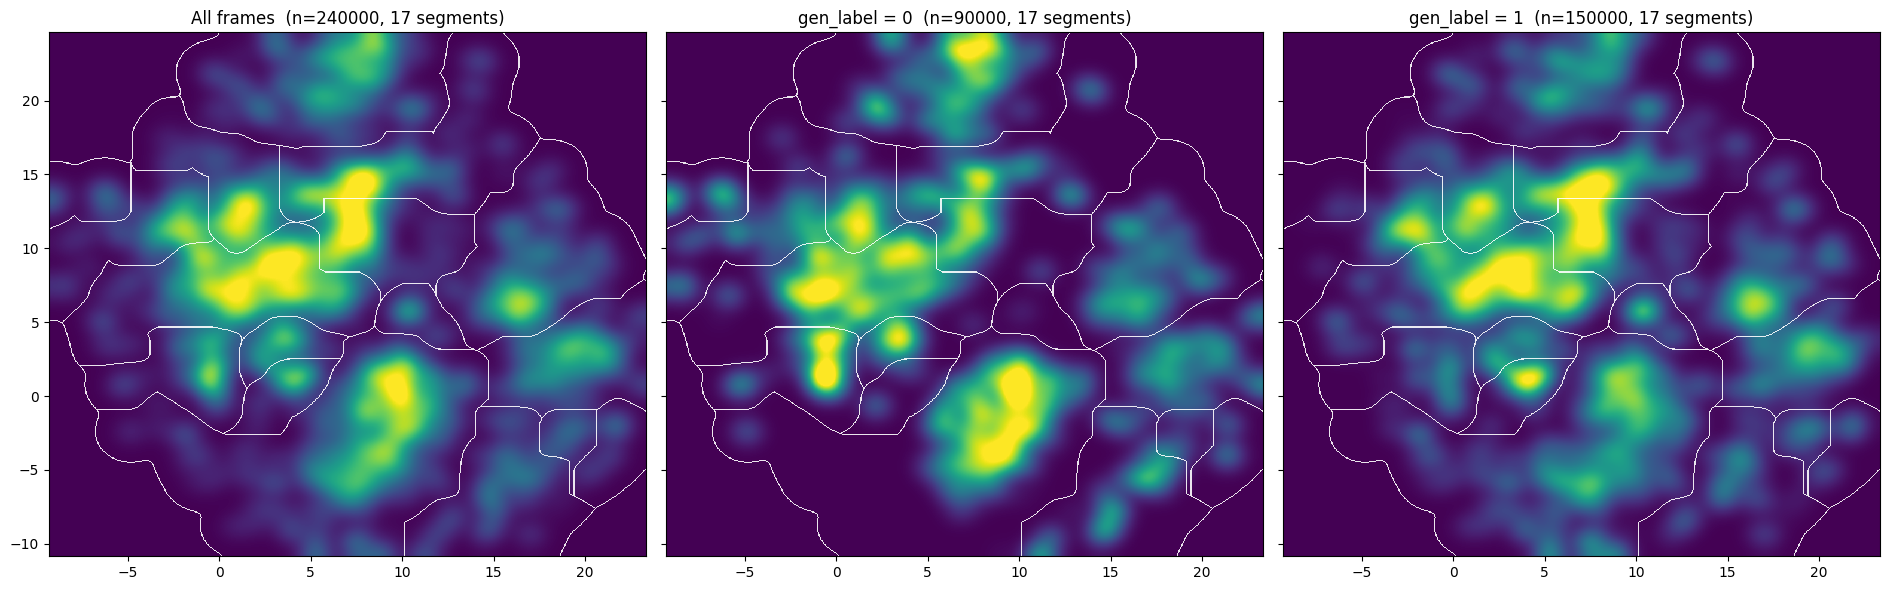

In [58]:
fig = plot_behavioral_map_3panel(df,  x_col="umap_x", y_col="umap_y", 
                                 sigma=20, threshold_rel=0.15, grid_size=1000, min_distance=50)
plt.show()

## ethogram

In [24]:
n_clusters = df['cluster'].nunique()
n_frames   = df['frame_idx'].max() + 1
cmap       = get_cmap('tab20', n_clusters)
cluster_ids = sorted(df['cluster'].unique())
cluster_colors = {c: cmap(i) for i, c in enumerate(cluster_ids)}


def plot_ethogram_with_distribution(df, seq_label = "gen_label", cluster_label = "cluster",
                                    sort_by_label=False, figsize_scale=0.25, colors = cluster_colors):
    """
    Left  : ethogram (time × sequence, colored by cluster)
    Right : horizontal stacked bar showing cluster fraction per sequence
    """

    # Sequence order
    seq_meta = (df.drop_duplicates('seq_id').set_index('seq_id')[[seq_label]].copy())
    if sort_by_label:
        seq_meta = seq_meta.sort_values(seq_label)
    seq_order = seq_meta.index.tolist()
    n_seqs    = len(seq_order)

    # Build ethogram image array
    img = np.ones((n_seqs, n_frames, 3))
    for row_i, sid in enumerate(seq_order):
        sub = df[df['seq_id'] == sid].sort_values('frame_idx')
        for _, r in sub.iterrows():
            img[row_i, int(r['frame_idx'])] = colors[r[cluster_label]][:3]

    # Build occupancy matrix: (n_seqs, n_clusters)
    occupancy = np.zeros((n_seqs, len(cluster_ids)))
    for row_i, sid in enumerate(seq_order):
        counts = df[df['seq_id'] == sid][cluster_label].value_counts()
        total  = counts.sum()
        for col_i, c in enumerate(cluster_ids):
            occupancy[row_i, col_i] = counts.get(c, 0) / total

    # Layout: ethogram gets ~75% width, distribution ~25%
    fig_h = max(4, n_seqs * figsize_scale + 2)
    fig   = plt.figure(figsize=(18, fig_h))
    gs    = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.04)
    ax_etho = fig.add_subplot(gs[0])
    ax_dist = fig.add_subplot(gs[1])

    # --- Ethogram ---
    ax_etho.imshow(img, aspect='auto', interpolation='nearest', extent=[0, n_frames, n_seqs, 0])

    ax_etho.set_yticks(np.arange(n_seqs) + 0.5)
    ax_etho.set_yticklabels([f"{seq_meta.loc[s, seq_label]} | {s}" for s in seq_order], fontsize=11)
    ax_etho.set_ylabel('Sequence')
    ax_etho.set_xlabel('Frame')
    ax_etho.set_title('Ethogram', fontsize=11)

    # Label group dividers + right-side annotations
    if sort_by_label:
        label_blocks = seq_meta[seq_label] != seq_meta[seq_label].shift()
        boundaries   = np.where(label_blocks)[0]
        for b in boundaries[1:]:
            ax_etho.axhline(b, color='white', lw=1.5)
            ax_dist.axhline(b, color='white', lw=1.5, zorder=5)
    # --- Stacked bar distribution ---
    lefts = np.zeros(n_seqs)
    for col_i, c in enumerate(cluster_ids):
        vals = occupancy[:, col_i]
        ax_dist.barh(np.arange(n_seqs) + 0.5, vals, left=lefts,
                     color=colors[c], height=0.85, linewidth=0)
        lefts += vals

    ax_dist.set_xlim(0, 1)
    ax_dist.set_ylim(n_seqs, 0)          # match ethogram y direction
    ax_dist.set_xlabel('Fraction')
    ax_dist.set_title('Cluster dist.', fontsize=11)
    ax_dist.set_yticks([])               # y labels already on ethogram
    ax_dist.set_xticks([0, 0.5, 1])
    ax_dist.xaxis.set_tick_params(labelsize=7)
    ax_dist.spines[['top', 'right', 'left']].set_visible(False)

    # --- Shared legend ---
    handles = [mpatches.Patch(color=colors[c], label=f'C{c}') for c in cluster_ids]
    fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.9),
               loc='upper left', fontsize=11, frameon=False,
               title='Cluster', title_fontsize=8)
    #plt.savefig('ethogram_with_distribution.pdf', dpi=150, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_34094/1219842215.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap       = get_cmap('tab20', n_clusters)


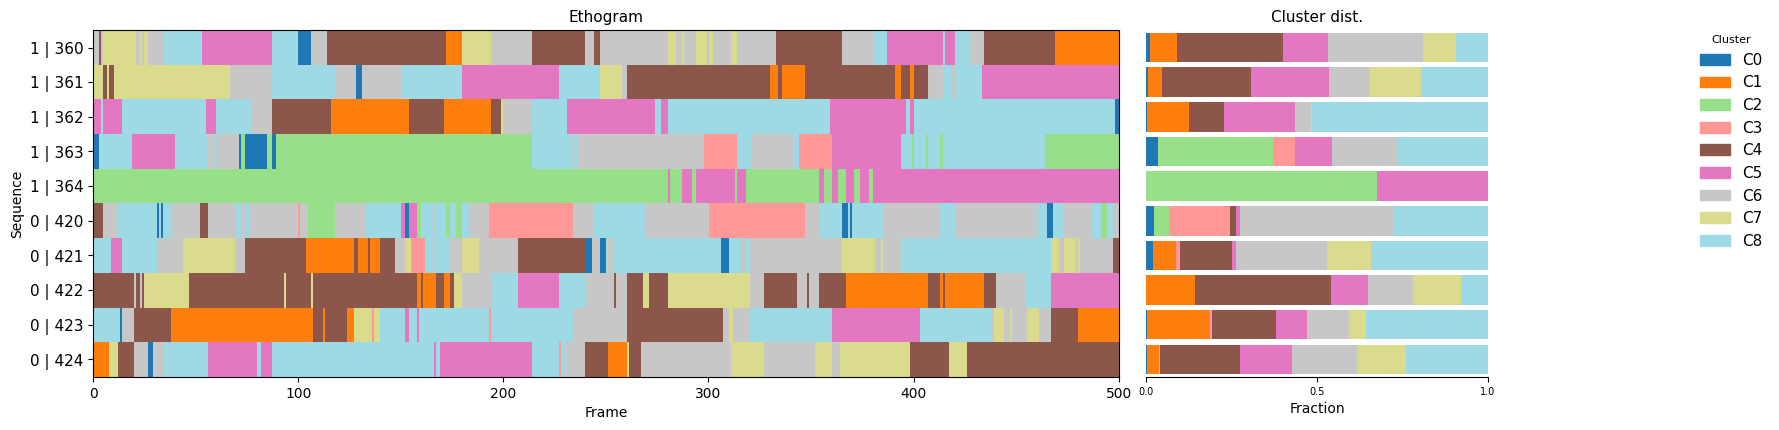

In [25]:
plot_ethogram_with_distribution(filter_dataframe_multiple(df, 
                                                          {#"mouse_label":["M1"],
                                                           'seq_id': [360, 361, 362, 363, 364, 420, 421, 422, 423, 424]
                                                          }), 
                                                            #cluster_label = "hlac_label"
                                                           )